# Predictive Maintenance Models - Main Dataset Experiments

## Impor Required Libraries

In [1]:
import os
import sys
import json
import textwrap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle

from imblearn.over_sampling import SMOTENC

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder

## Dataset Loading

Dataset Sources:
- https://www.kaggle.com/datasets/shivamb/machine-predictive-maintenance-classification


### Load the Datasets

In [2]:
df_predictive_maintenance = pd.read_csv('data/predictive_maintenance.csv')

### Predictive Maintenance Dataset

In [3]:
df_predictive_maintenance.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


## Define the Category, Numeric and Target

In [4]:
# Predictive Maintenance Dataset
df_predictive_maintenance_id = ["UDI", "Product ID"]
df_predictive_maintenance_category = ["Type"]
df_predictive_maintenance_target = ["Target", "Failure Type"]
df_predictive_maintenance_numeric = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

## Auto Dataset Assessing

In [5]:
def assess_dataframe(df, target=None, high_card_threshold=0.5):
    print("Data Assessment Report")

    n_rows, n_cols = df.shape
    print(f"\nShape of Dataset: {n_rows} Rows x {n_cols} Columns")

    print("\nColumn Information:")
    info_table = pd.DataFrame({
        "DataType": df.dtypes,
        "Non-Null Count": df.notnull().sum(),
        "Null Count": df.isnull().sum(),
        "Null %": (df.isnull().sum() / n_rows * 100).round(2),
        "Unique Values": df.nunique(dropna=True),
        "Unique %": (df.nunique(dropna=True) / n_rows * 100).round(2),
    })
    print(info_table)

    dup_count = df.duplicated().sum()
    dup_percent = round((dup_count / n_rows) * 100, 2) if n_rows else 0.0
    print(f"\nDuplicate Rows: {dup_count} ({dup_percent}%)")

    const_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
    print("\nConstant Columns:")
    print(const_cols if const_cols else "None")

    cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
    high_card_cols = []
    for c in cat_cols:
        ratio = (df[c].nunique(dropna=True) / n_rows) if n_rows else 0.0
        if ratio >= high_card_threshold:
            high_card_cols.append((c, round(ratio*100, 2)))
    print("\nHigh Cardinality Categorical Columns (>= {:.0f}% Unique):".format(high_card_threshold*100))
    if high_card_cols:
        for c, pct in high_card_cols:
            print(f"- {c}: {pct}% Unique")
    else:
        print("None")

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if num_cols:
        print("\nNumeric Columns Summary:")
        modes = {}
        if len(num_cols) > 0:
            mode_df = df[num_cols].mode(dropna=True)
            for c in num_cols:
                modes[c] = mode_df[c].iloc[0] if not mode_df.empty and c in mode_df else np.nan
        summary = pd.DataFrame({
            "Mean": df[num_cols].mean(numeric_only=True),
            "Median": df[num_cols].median(numeric_only=True),
            "Mode": pd.Series(modes),
            "Min": df[num_cols].min(numeric_only=True),
            "Q1": df[num_cols].quantile(0.25, numeric_only=True),
            "Q3": df[num_cols].quantile(0.75, numeric_only=True),
            "Max": df[num_cols].max(numeric_only=True),
            "Standard Deviation": df[num_cols].std(numeric_only=True),
            "Skewness": df[num_cols].skew(numeric_only=True),
            "Kurtosis": df[num_cols].kurt(numeric_only=True)
        }).round(4)
        print(summary)

        print("\nOutlier Counts (IQR method):")
        outlier_rows = []
        for c in num_cols:
            series = df[c].dropna()
            if series.empty:
                outlier_rows.append((c, 0, 0.0))
                continue
            q1 = series.quantile(0.25)
            q3 = series.quantile(0.75)
            iqr = q3 - q1
            if iqr == 0:
                outlier_rows.append((c, 0, 0.0))
                continue
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            count = ((series < lower) | (series > upper)).sum()
            pct = round(count / len(series) * 100, 2)
            outlier_rows.append((c, int(count), pct))
        if outlier_rows:
            outlier_table = pd.DataFrame(outlier_rows, columns=["Column", "Outliers", "Outliers %"])
            print(outlier_table)

        print("\nPearson Correlation (Numeric):")
        pearson_corr = df[num_cols].corr(method="pearson")
        print(pearson_corr.round(3))

        print("\nSpearman Correlation (Numeric):")
        spearman_corr = df[num_cols].corr(method="spearman")
        print(spearman_corr.round(3))
    else:
        print("\nNo Numeric columns found.")

    print("\nColumns > 50% Missing Values:")
    high_missing = info_table[info_table["Null %"] > 50].sort_values("Null %", ascending=False)
    if not high_missing.empty:
        print(high_missing[["Null Count", "Null %"]])
    else:
        print("None")

    print("\nMemory Usage:")
    total_mem = df.memory_usage(deep=True).sum()
    print(f"Total: {total_mem} bytes ({round(total_mem/1024,2)} KB, {round(total_mem/(1024*1024),2)} MB)")
    memory_per_col = df.memory_usage(deep=True)
    memory_table = pd.DataFrame({"Bytes": memory_per_col}).sort_values("Bytes", ascending=False)
    print("\nPer Column Memory:")
    print(memory_table)

    if target is not None and target in df.columns:
        print(f"\nClass Balance for '{target}':")
        vc = df[target].value_counts(dropna=False)
        vp = df[target].value_counts(normalize=True, dropna=False).mul(100).round(2)
        bal = pd.DataFrame({"Count": vc, "Percent %": vp})
        print(bal)

    print("\nData Assessment Completed")

## Expl(ora/ana)tory Data Analysis - Predictive Maintenance Dataset

### Assessing Dataset with Different Target

In [6]:
assess_dataframe(df_predictive_maintenance, target=df_predictive_maintenance_target[0])


Data Assessment Report

Shape of Dataset: 10000 Rows x 10 Columns

Column Information:
                        DataType  Non-Null Count  Null Count  Null %  \
UDI                        int64           10000           0     0.0   
Product ID                object           10000           0     0.0   
Type                      object           10000           0     0.0   
Air temperature [K]      float64           10000           0     0.0   
Process temperature [K]  float64           10000           0     0.0   
Rotational speed [rpm]     int64           10000           0     0.0   
Torque [Nm]              float64           10000           0     0.0   
Tool wear [min]            int64           10000           0     0.0   
Target                     int64           10000           0     0.0   
Failure Type              object           10000           0     0.0   

                         Unique Values  Unique %  
UDI                              10000    100.00  
Product ID        

In [7]:
assess_dataframe(df_predictive_maintenance, target=df_predictive_maintenance_target[1])


Data Assessment Report

Shape of Dataset: 10000 Rows x 10 Columns

Column Information:
                        DataType  Non-Null Count  Null Count  Null %  \
UDI                        int64           10000           0     0.0   
Product ID                object           10000           0     0.0   
Type                      object           10000           0     0.0   
Air temperature [K]      float64           10000           0     0.0   
Process temperature [K]  float64           10000           0     0.0   
Rotational speed [rpm]     int64           10000           0     0.0   
Torque [Nm]              float64           10000           0     0.0   
Tool wear [min]            int64           10000           0     0.0   
Target                     int64           10000           0     0.0   
Failure Type              object           10000           0     0.0   

                         Unique Values  Unique %  
UDI                              10000    100.00  
Product ID        

### Histogram & KDE of Numeric Features

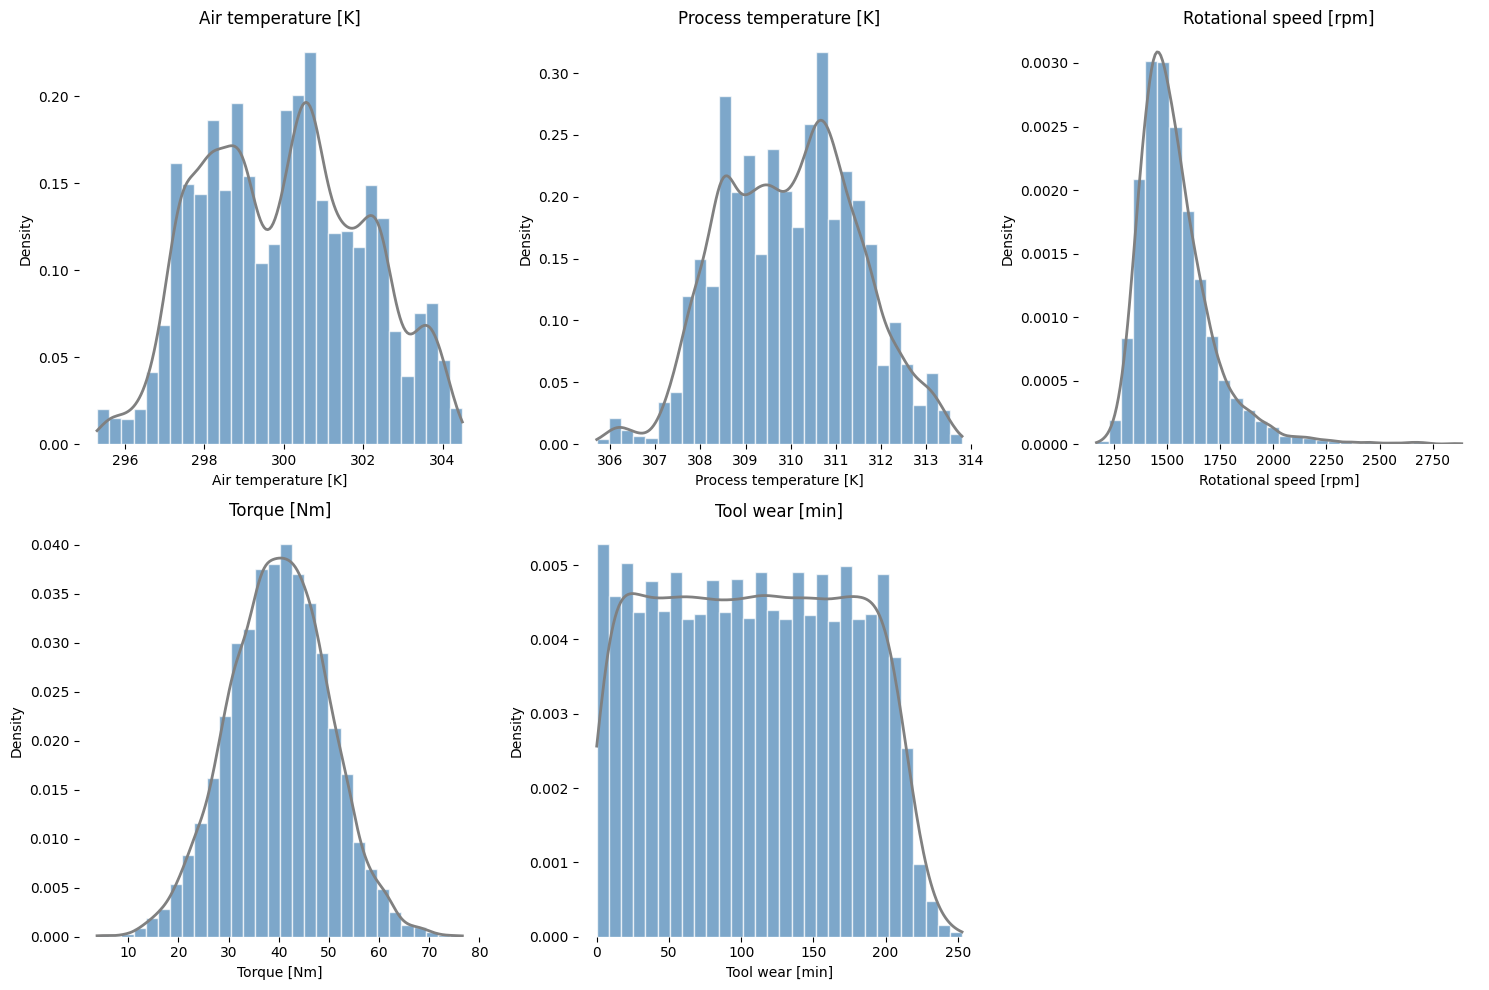

In [8]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(df_predictive_maintenance_numeric, 1):
    plt.subplot(2, 3, i)
    
    plt.hist(df_predictive_maintenance[col], bins=30, density=True, color='steelblue', alpha=0.7, edgecolor='white')

    kde = gaussian_kde(df_predictive_maintenance[col].dropna())
    x_vals = np.linspace(df_predictive_maintenance[col].min(), df_predictive_maintenance[col].max(), 200)
    plt.plot(x_vals, kde(x_vals), color="gray", linewidth=2)
    
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.title(col)
    
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()

### Distribution of Category - `Type`

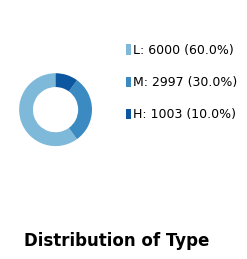

In [9]:
rows, cols = 2, 4
fig = plt.figure(figsize=(16, 9))
gs = GridSpec(rows, cols, figure=fig, wspace=0.6, hspace=0.9)

for idx, col in enumerate(df_predictive_maintenance_category):
    r, c = divmod(idx, cols)

    cell = gs[r, c].subgridspec(
        2, 2,
        height_ratios=[12, 1],
        width_ratios=[3.0, 3.4]
    )
    ax_pie   = fig.add_subplot(cell[0, 0])
    ax_leg   = fig.add_subplot(cell[0, 1])
    ax_title = fig.add_subplot(cell[1, :])

    vals = df_predictive_maintenance[col].value_counts()
    labels = vals.index.to_list()
    sizes  = vals.values
    total  = sizes.sum()

    cmap   = plt.get_cmap("Blues")
    colors = cmap(np.linspace(0.45, 0.85, len(vals)))

    ax_pie.pie(
        sizes, startangle=90, colors=colors,
        wedgeprops=dict(width=0.38), labels=None
    )
    ax_pie.set_aspect('equal')
    ax_pie.set_xticks([]); ax_pie.set_yticks([])

    ax_leg.set_xlim(0, 1); ax_leg.set_ylim(0, 1)
    ax_leg.axis('off')

    n = len(labels)
    y_top = 0.80
    dy = min(0.16, 0.9 / (n + 1))

    for i, (lab, cnt, color) in enumerate(zip(labels, sizes, colors)):
        y = y_top - i * dy

        ax_leg.add_patch(Rectangle((0.05, y - 0.025), 0.05, 0.05, facecolor=color, edgecolor='none'))

        ax_leg.text(0.12, y, f"{lab}: {cnt} ({cnt/total:.1%})",
                    va='center', ha='left', fontsize=9)

    ax_title.axis('off')
    ax_title.text(0.5, 0.5, f"Distribution of {col}",
                  ha='center', va='center', fontsize=12, fontweight='bold')

plt.show()

### Distribution of Target 1 -  `Target`

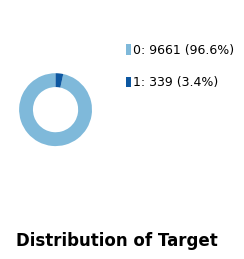

In [10]:
rows, cols = 2, 4
fig = plt.figure(figsize=(16, 9))
gs = GridSpec(rows, cols, figure=fig, wspace=0.6, hspace=0.9)

for idx, col in enumerate(df_predictive_maintenance_target[0:1]):
    r, c = divmod(idx, cols)

    cell = gs[r, c].subgridspec(
        2, 2,
        height_ratios=[12, 1],
        width_ratios=[3.0, 3.4]
    )
    ax_pie   = fig.add_subplot(cell[0, 0])
    ax_leg   = fig.add_subplot(cell[0, 1])
    ax_title = fig.add_subplot(cell[1, :])

    vals = df_predictive_maintenance[col].value_counts()
    labels = vals.index.to_list()
    sizes  = vals.values
    total  = sizes.sum()

    cmap   = plt.get_cmap("Blues")
    colors = cmap(np.linspace(0.45, 0.85, len(vals)))

    ax_pie.pie(
        sizes, startangle=90, colors=colors,
        wedgeprops=dict(width=0.38), labels=None
    )
    ax_pie.set_aspect('equal')
    ax_pie.set_xticks([]); ax_pie.set_yticks([])

    ax_leg.set_xlim(0, 1); ax_leg.set_ylim(0, 1)
    ax_leg.axis('off')

    n = len(labels)
    y_top = 0.80
    dy = min(0.16, 0.9 / (n + 1))

    for i, (lab, cnt, color) in enumerate(zip(labels, sizes, colors)):
        y = y_top - i * dy

        ax_leg.add_patch(Rectangle((0.05, y - 0.025), 0.05, 0.05, facecolor=color, edgecolor='none'))

        ax_leg.text(0.12, y, f"{lab}: {cnt} ({cnt/total:.1%})",
                    va='center', ha='left', fontsize=9)

    ax_title.axis('off')
    ax_title.text(0.5, 0.5, f"Distribution of {col}",
                  ha='center', va='center', fontsize=12, fontweight='bold')

plt.show()

### Distribution of Target 2 - `Failure Type`

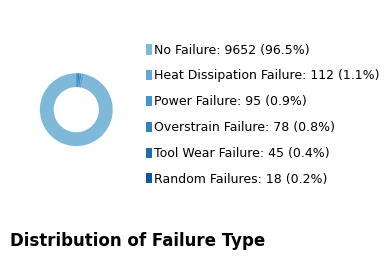

In [11]:
rows, cols = 2, 4
fig = plt.figure(figsize=(16, 9))
gs = GridSpec(rows, cols, figure=fig, wspace=0.6, hspace=0.9)

for idx, col in enumerate(df_predictive_maintenance_target[1:2]):
    r, c = divmod(idx, cols)

    cell = gs[r, c].subgridspec(
        2, 2,
        height_ratios=[12, 1],
        width_ratios=[3.0, 3.4]
    )
    ax_pie   = fig.add_subplot(cell[0, 0])
    ax_leg   = fig.add_subplot(cell[0, 1])
    ax_title = fig.add_subplot(cell[1, :])

    vals = df_predictive_maintenance[col].value_counts()
    labels = vals.index.to_list()
    sizes  = vals.values
    total  = sizes.sum()

    cmap   = plt.get_cmap("Blues")
    colors = cmap(np.linspace(0.45, 0.85, len(vals)))

    ax_pie.pie(
        sizes, startangle=90, colors=colors,
        wedgeprops=dict(width=0.38), labels=None
    )
    ax_pie.set_aspect('equal')
    ax_pie.set_xticks([]); ax_pie.set_yticks([])

    ax_leg.set_xlim(0, 1); ax_leg.set_ylim(0, 1)
    ax_leg.axis('off')

    n = len(labels)
    y_top = 0.80
    dy = min(0.16, 0.9 / (n + 1))

    for i, (lab, cnt, color) in enumerate(zip(labels, sizes, colors)):
        y = y_top - i * dy

        ax_leg.add_patch(Rectangle((0.05, y - 0.025), 0.05, 0.05, facecolor=color, edgecolor='none'))

        ax_leg.text(0.12, y, f"{lab}: {cnt} ({cnt/total:.1%})",
                    va='center', ha='left', fontsize=9)

    ax_title.axis('off')
    ax_title.text(0.5, 0.5, f"Distribution of {col}",
                  ha='center', va='center', fontsize=12, fontweight='bold')

plt.show()

### Correlation Matrix - Target 1

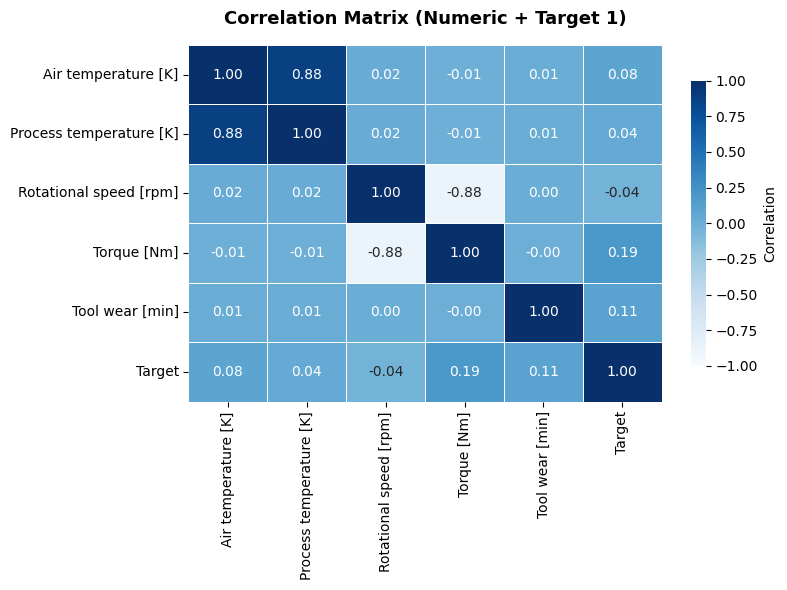

In [12]:
plt.figure(figsize=(8, 6))

corr_matrix = df_predictive_maintenance[df_predictive_maintenance_numeric + [df_predictive_maintenance_target[0]]].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1,
    cbar_kws={"shrink": 0.8, "label": "Correlation"}
)

plt.title("Correlation Matrix (Numeric + Target 1)", fontsize=13, pad=15, fontweight="bold")
plt.xticks(rotation=90, ha='center')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Data Preprocessing

### Change Columns Name

In [13]:
column_rename_map = {
    # Identifiers
    "UDI": "unit_id",
    "Product ID": "product_id",
    # Categorical
    "Type": "engine_type",
    
    # Targets
    "Target": "target",
    "Failure Type": "failure_type",
    
    # Numeric
    "Air temperature [K]": "air_temp",
    "Process temperature [K]": "process_temp",
    "Rotational speed [rpm]": "rpm",
    "Torque [Nm]": "torque_nm",
    "Tool wear [min]": "tool_wear",
}

df_predictive_maintenance = df_predictive_maintenance.rename(columns=column_rename_map)
df_predictive_maintenance.head()

,unit_id,product_id,engine_type,air_temp,process_temp,rpm,torque_nm,tool_wear,target,failure_type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


### Defined Constant & Variables

In [14]:
from datetime import datetime, timedelta
from pathlib import Path

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Choose scaler: "standard" or "minmax"
SCALER_TYPE = "standard" # set to "minmax" if you prefer MinMaxScaler

# Split ratio
TEST_SIZE = 0.20

# Timestamp synthesis cadence
TS_STEP_MINUTES = 10

OUT_DIR = Path("processed"); OUT_DIR.mkdir(exist_ok=True, parents=True)

NUMERIC_COLS = ["air_temp", "process_temp", "rpm", "torque_nm", "tool_wear"]
CAT_COLS = ["engine_type"]

def log_info(msg): 
    print(f"[INFO] {msg}")
    
def log_res(msg):  
    print(f"[RESULT] {msg}")
    
def get_scaler():
    return StandardScaler() if SCALER_TYPE == "standard" else MinMaxScaler()

### Preprocessing Function

In [15]:
def fit_transform_cat_for_smotenc(df_cat: pd.DataFrame):
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    arr = enc.fit_transform(df_cat)
    df_enc = pd.DataFrame(arr, columns=df_cat.columns, index=df_cat.index)
    return enc, df_enc

def transform_cat(enc: OrdinalEncoder, df_cat: pd.DataFrame):
    arr = enc.transform(df_cat)
    return pd.DataFrame(arr, columns=df_cat.columns, index=df_cat.index)

def smotenc_resample(X_mix: pd.DataFrame, y: pd.Series, cat_cols: list, random_state=SEED):
    cat_idx = [X_mix.columns.get_loc(c) for c in cat_cols]
    sm = SMOTENC(categorical_features=cat_idx, random_state=random_state)
    X_res, y_res = sm.fit_resample(X_mix.values, y.values)
    return X_res, y_res

def add_synthetic_timestamps(df_like: pd.DataFrame, group_col="unit_id", start=None, step_minutes=TS_STEP_MINUTES):
    if start is None:
        start = datetime.now()
    dfx = df_like.sort_values([group_col]).reset_index(drop=True)
    dfx["timestamp"] = dfx.groupby(group_col).cumcount().apply(
        lambda k: start + timedelta(minutes=step_minutes*k)
    )
    return dfx

def assign_unit_ids_like(dfx_len: int, unit_pool: np.ndarray):
    if len(unit_pool) == 0:
        # Fallback single unit if pool is empty
        unit_pool = np.array([0])
    return np.random.choice(unit_pool, size=dfx_len, replace=True)

def pack_and_save(
    X_arr, y_arr, enc: OrdinalEncoder, scaler, base_df_pool: pd.DataFrame,
    out_path: Path, note: str
):
    # Reconstruct a human-readable DataFrame:
    # X_arr columns order = CAT_COLS + NUMERIC_COLS
    cols = CAT_COLS + NUMERIC_COLS
    tmp = pd.DataFrame(X_arr, columns=cols)

    # Inverse transform categorical to original labels
    tmp_cat = tmp[CAT_COLS].round().clip(lower=-1).astype(int)  # defensive cast
    tmp[CAT_COLS] = enc.inverse_transform(tmp_cat.values)

    # Attach unit_id sampled from the pool (to keep per-unit group structure plausible)
    unit_pool = base_df_pool["unit_id"].values
    tmp["unit_id"] = assign_unit_ids_like(len(tmp), unit_pool)

    # Attach product_id sampled from pool as well (optional, for richer schema)
    if "product_id" in base_df_pool.columns:
        prod_pool = base_df_pool["product_id"].values
        tmp["product_id"] = np.random.choice(prod_pool, size=len(tmp), replace=True)

    # Attach y
    tmp["target"] = y_arr.astype(int)

    # Timestamp synthesis (applied outside when needed; here we only save if already present)
    # Save
    tmp = tmp[["unit_id", "product_id"] + CAT_COLS + NUMERIC_COLS + ["target"] + ([ "timestamp"] if "timestamp" in tmp.columns else [])]
    tmp.to_csv(out_path, index=False)
    log_res(f"Saved {note}: {out_path.name} ({len(tmp)} rows)")
    return tmp

### Anti-Leakage Preprocessing (Split > Normalize > Balancing > Timestamp)

In [16]:
# 1) Split first
X_all = df_predictive_maintenance[CAT_COLS + NUMERIC_COLS].copy()
y_all = df_predictive_maintenance["target"].copy()

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, stratify=y_all, random_state=SEED
)
log_info(f"[A] Split done. Train: {X_train_df.shape}, Test: {X_test_df.shape}")

# 2) Normalize numeric (fit on train)
scaler_A = get_scaler()
X_train_num = pd.DataFrame(
    scaler_A.fit_transform(X_train_df[NUMERIC_COLS]),
    columns=NUMERIC_COLS, index=X_train_df.index
)
X_test_num = pd.DataFrame(
    scaler_A.transform(X_test_df[NUMERIC_COLS]),
    columns=NUMERIC_COLS, index=X_test_df.index
)

# 3) Encode categorical for SMOTENC
enc_A, X_train_cat_enc = fit_transform_cat_for_smotenc(X_train_df[CAT_COLS])
X_test_cat_enc = transform_cat(enc_A, X_test_df[CAT_COLS])

# 4) Build mixed matrices
X_train_mix = pd.concat([X_train_cat_enc, X_train_num], axis=1)
X_test_mix  = pd.concat([X_test_cat_enc,  X_test_num], axis=1)

# 5) Balance only the training set
X_tr_res_A, y_tr_res_A = smotenc_resample(X_train_mix, y_train, CAT_COLS, random_state=SEED)

# 6) Timestamp synthesis after resampling
# Rebuild train frame with unit_id/product_id from the TRAIN pool
train_pool = df_predictive_maintenance.loc[X_train_df.index, ["unit_id", "product_id"]].copy()
test_pool  = df_predictive_maintenance.loc[X_test_df.index,  ["unit_id", "product_id"]].copy()

train_path_A = OUT_DIR / "anti-leakage-dataset_train.csv"
test_path_A  = OUT_DIR / "anti-leakage-dataset_test.csv"

train_df_A = pack_and_save(
    X_tr_res_A, y_tr_res_A, enc_A, scaler_A, train_pool, train_path_A, note="[A] Train"
)
test_df_A = pack_and_save(
    X_test_mix.values, y_test.values, enc_A, scaler_A, test_pool, test_path_A, note="[A] Test"
)

# Add timestamps per unit_id
train_df_A = add_synthetic_timestamps(train_df_A, group_col="unit_id", step_minutes=TS_STEP_MINUTES)
test_df_A  = add_synthetic_timestamps(test_df_A,  group_col="unit_id", step_minutes=TS_STEP_MINUTES)

# Overwrite with timestamped versions
train_df_A.to_csv(train_path_A, index=False)
test_df_A.to_csv(test_path_A, index=False)

log_res(f"[A] Final saved: {train_path_A.name}, {test_path_A.name}")
display(train_df_A.head())
display(test_df_A.head())

[INFO] [A] Split done. Train: (8000, 6), Test: (2000, 6)
[RESULT] Saved [A] Train: anti-leakage-dataset_train.csv (15458 rows)
[RESULT] Saved [A] Test: anti-leakage-dataset_test.csv (2000 rows)
[RESULT] [A] Final saved: anti-leakage-dataset_train.csv, anti-leakage-dataset_test.csv


,unit_id,product_id,engine_type,air_temp,process_temp,rpm,torque_nm,tool_wear,target,timestamp
0,1,M16212,M,0.448010,0.874673,1.445769,-1.537428,-0.120818,0,2025-11-07 22:22:05.611405
1,3,L53367,L,0.397928,0.807075,-0.786625,0.868022,0.052116,0,2025-11-07 22:22:05.611405
2,3,M17819,L,-0.804044,-1.220858,1.716529,-1.297881,1.356983,0,2025-11-07 22:32:05.611405
3,3,L56429,M,0.347846,0.401488,-0.554545,0.169343,1.199770,0,2025-11-07 22:42:05.611405
4,3,H37423,L,1.360491,0.726528,-1.017055,0.931084,0.992603,1,2025-11-07 22:52:05.611405


,unit_id,product_id,engine_type,air_temp,process_temp,rpm,torque_nm,tool_wear,target,timestamp
0,2,M16979,L,0.748503,0.469086,0.434561,-0.449486,1.734294,0,2025-11-07 22:22:05.647278
1,2,H34005,L,-1.354948,-1.288455,-0.184321,-0.399580,0.665246,0,2025-11-07 22:32:05.647278
2,2,L52545,L,1.549817,0.807075,-0.482710,1.287228,-1.520013,0,2025-11-07 22:42:05.647278
3,5,L56007,M,-1.905851,-2.032031,3.202950,-2.166238,0.806738,0,2025-11-07 22:22:05.647278
4,12,H30006,L,-1.405030,-1.018064,-0.377721,0.169343,-1.048374,0,2025-11-07 22:22:05.647278


### Sythesize Preprocessing (Normallize > Balancing > Timestamp > Split)

In [17]:
# 1) Normalize numeric on the FULL dataset (intentional leakage for this design)
scaler_B = get_scaler()
X_num_B = pd.DataFrame(
    scaler_B.fit_transform(df_predictive_maintenance[NUMERIC_COLS]),
    columns=NUMERIC_COLS, index=df_predictive_maintenance.index
)

# 2) Encode categorical on FULL dataset
enc_B, X_cat_enc_B = fit_transform_cat_for_smotenc(df_predictive_maintenance[CAT_COLS])

# 3) Combine, then SMOTENC on FULL dataset
X_mix_B = pd.concat([X_cat_enc_B, X_num_B], axis=1)
y_B = df_predictive_maintenance["target"].copy()

X_full_res_B, y_full_res_B = smotenc_resample(X_mix_B, y_B, CAT_COLS, random_state=SEED)
log_info(f"[B] After SMOTENC full: {X_full_res_B.shape}")

# 4) Timestamp synthesis on the resampled FULL set
# Build frame and assign unit_id/product_id sampled from the full pool
full_pool = df_predictive_maintenance[["unit_id", "product_id"]].copy()
full_path_tmp = OUT_DIR / "_tmp_synthesize_full.csv"
full_df_B = pack_and_save(
    X_full_res_B, y_full_res_B, enc_B, scaler_B, full_pool, full_path_tmp, note="[B] Full (tmp)"
)
# Add timestamps
full_df_B = add_synthetic_timestamps(full_df_B, group_col="unit_id", step_minutes=TS_STEP_MINUTES)

# 5) Now split AFTER normalization+balancing+timestamps
X_B = full_df_B[["unit_id", "product_id"] + CAT_COLS + NUMERIC_COLS + ["timestamp"]].copy()
y_B = full_df_B["target"].copy()

X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y_B, test_size=TEST_SIZE, stratify=y_B, random_state=SEED
)

# 6) Save final train/test for synthesize-first design
train_path_B = OUT_DIR / "synthesize-dataset_train.csv"
test_path_B  = OUT_DIR / "synthesize-dataset_test.csv"

train_df_B = pd.concat([X_train_B, y_train_B], axis=1)
test_df_B  = pd.concat([X_test_B,  y_test_B], axis=1)

train_df_B.to_csv(train_path_B, index=False)
test_df_B.to_csv(test_path_B, index=False)

# Clean temp
try:
    full_path_tmp.unlink(missing_ok=True)
except Exception:
    pass

log_res(f"[B] Final saved: {train_path_B.name}, {test_path_B.name}")
display(train_df_B.head())
display(test_df_B.head())

[INFO] [B] After SMOTENC full: (19322, 6)
[RESULT] Saved [B] Full (tmp): _tmp_synthesize_full.csv (19322 rows)
[RESULT] [B] Final saved: synthesize-dataset_train.csv, synthesize-dataset_test.csv


,unit_id,product_id,engine_type,air_temp,process_temp,rpm,torque_nm,tool_wear,timestamp,target
2948,1554,L48487,L,0.495280,0.665781,-0.787090,1.809458,1.293572,2025-11-07 22:22:06.277625,1
18384,9524,L55153,M,1.003197,0.359782,-0.944912,0.692010,-0.575376,2025-11-07 22:22:06.277625,1
13168,6807,L50305,H,0.197519,0.468059,0.653877,-0.369858,0.299273,2025-11-07 22:22:06.277625,0
5269,2716,L52918,L,1.489503,1.209468,-0.835994,1.426781,1.571838,2025-11-07 22:22:06.277625,1
3111,1636,H38064,M,1.697400,1.209468,-1.103199,0.703530,1.603259,2025-11-07 22:32:06.277625,1


,unit_id,product_id,engine_type,air_temp,process_temp,rpm,torque_nm,tool_wear,timestamp,target
1077,549,M24699,L,0.960262,0.590325,-0.920673,1.403150,1.585008,2025-11-07 22:32:06.277625,1
18648,9658,M16564,L,-1.002385,-1.553968,0.374976,-0.921600,-1.428902,2025-11-07 22:32:06.277625,0
15990,8259,L54065,L,1.014295,0.543027,0.484673,-1.086402,1.966040,2025-11-07 22:42:06.277625,1
8001,4115,L48544,M,0.247515,0.939865,1.139165,-1.242613,-0.973292,2025-11-07 22:22:06.277625,0
8582,4424,L50930,L,-1.276963,-1.072378,-0.953087,1.088695,1.745544,2025-11-07 22:32:06.277625,1


In [18]:
from collections import OrderedDict

summary = OrderedDict({
    "Anti-Leakage (train)": OUT_DIR / "anti-leakage-dataset_train.csv",
    "Anti-Leakage (test)":  OUT_DIR / "anti-leakage-dataset_test.csv",
    "Synthesize (train)":   OUT_DIR / "synthesize-dataset_train.csv",
    "Synthesize (test)":    OUT_DIR / "synthesize-dataset_test.csv",
})

for k, p in summary.items():
    print(f"{k}: {p} | exists={p.exists()} | bytes={p.stat().st_size if p.exists() else 'NA'}")

# Quick schema check
anti_leakage = pd.read_csv("processed/anti-leakage-dataset_train.csv")
synthesize_balanced = pd.read_csv("processed/synthesize-dataset_train.csv")

print("\nAnti-Leakage Dataset:")
display(anti_leakage.head())
print("\nSynthesize Dataset:")
display(synthesize_balanced.head())

Anti-Leakage (train): processed\anti-leakage-dataset_train.csv | exists=True | bytes=2183235
Anti-Leakage (test): processed\anti-leakage-dataset_test.csv | exists=True | bytes=284084
Synthesize (train): processed\synthesize-dataset_train.csv | exists=True | bytes=2182543
Synthesize (test): processed\synthesize-dataset_test.csv | exists=True | bytes=545701

Anti-Leakage Dataset:


,unit_id,product_id,engine_type,air_temp,process_temp,rpm,torque_nm,tool_wear,target,timestamp
0,1,M16212,M,0.448010,0.874673,1.445769,-1.537428,-0.120818,0,2025-11-07 22:22:05.611405
1,3,L53367,L,0.397928,0.807075,-0.786625,0.868022,0.052116,0,2025-11-07 22:22:05.611405
2,3,M17819,L,-0.804044,-1.220858,1.716529,-1.297881,1.356983,0,2025-11-07 22:32:05.611405
3,3,L56429,M,0.347846,0.401488,-0.554545,0.169343,1.199770,0,2025-11-07 22:42:05.611405
4,3,H37423,L,1.360491,0.726528,-1.017055,0.931084,0.992603,1,2025-11-07 22:52:05.611405



Synthesize Dataset:


,unit_id,product_id,engine_type,air_temp,process_temp,rpm,torque_nm,tool_wear,timestamp,target
0,1554,L48487,L,0.495280,0.665781,-0.787090,1.809458,1.293572,2025-11-07 22:22:06.277625,1
1,9524,L55153,M,1.003197,0.359782,-0.944912,0.692010,-0.575376,2025-11-07 22:22:06.277625,1
2,6807,L50305,H,0.197519,0.468059,0.653877,-0.369858,0.299273,2025-11-07 22:22:06.277625,0
3,2716,L52918,L,1.489503,1.209468,-0.835994,1.426781,1.571838,2025-11-07 22:22:06.277625,1
4,1636,H38064,M,1.697400,1.209468,-1.103199,0.703530,1.603259,2025-11-07 22:32:06.277625,1


## Modelling

### Defined Configurations - Helpers - Dataset Selection

In [19]:
# DATASET SELECTION
DATASET_CHOICE = "synth"   # "anti" → anti-leakage-dataset_*.csv
                          # "synth" → synthesize-dataset_*.csv

# MODEL / EVAL CONFIG
SEED = 42
THRESH = 0.50            # classification decision threshold
MAX_DAYS = 7             # horizon for maintenance scheduling
RANDOMIZE_DAYS = False   # set True only for demo jitter
JITTER_RANGE = 1         # +/- jitter in days if RANDOMIZE_DAYS=True

SEQ_LEN = 2            # LSTM sliding window length (sequence length)

# FEATURE SCHEMA
NUMERIC_FEATS = ["air_temp", "process_temp", "rpm", "torque_nm", "tool_wear"]
CAT_FEAT      = "engine_type" # MUST be numeric already; if not, we encode in-memory only
ID_FEATS      = ["unit_id", "product_id"]

np.random.seed(SEED)

DATA_DIR = Path("processed")
if DATASET_CHOICE == "anti":
    TRAIN_CSV = DATA_DIR / "anti-leakage-dataset_train.csv"
    TEST_CSV  = DATA_DIR / "anti-leakage-dataset_test.csv"
elif DATASET_CHOICE == "synth":
    TRAIN_CSV = DATA_DIR / "synthesize-dataset_train.csv"
    TEST_CSV  = DATA_DIR / "synthesize-dataset_test.csv"
else:
    raise ValueError("DATASET_CHOICE must be 'anti' or 'synth'.")

ARTIFACT_DIR = Path("artifacts") / DATASET_CHOICE
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

def info(msg): print(f"[INFO] {msg}")
def warn(msg): print(f"[WARN] {msg}")
def res(msg):  print(f"[RESULT] {msg}")

def prob_to_days(p: float, max_days: int = MAX_DAYS,
                 randomize: bool = RANDOMIZE_DAYS, jitter: int = JITTER_RANGE) -> int:
    """
    Deterministic monotone mapping: higher probability -> sooner maintenance.
    days = 1 + round((1 - p) * (max_days - 1)), clipped to [1, max_days].
    Optional small jitter for demos (disabled by default).
    """
    base = 1 + int(round((1.0 - float(p)) * (max_days - 1)))
    if randomize and jitter > 0:
        base += np.random.randint(-jitter, jitter + 1)
    return int(np.clip(base, 1, max_days))


### Load Preprocessed Dataset

In [20]:
assert TRAIN_CSV.exists(), f"[ERROR] Missing: {TRAIN_CSV}"
assert TEST_CSV.exists(),  f"[ERROR] Missing: {TEST_CSV}"

train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

required = set(ID_FEATS + [CAT_FEAT] + NUMERIC_FEATS + ["target"])

miss_tr = required - set(train_df.columns)
miss_te = required - set(test_df.columns)

assert not miss_tr, f"[ERROR] Train missing columns: {miss_tr}"
assert not miss_te, f"[ERROR] Test missing columns: {miss_te}"

HAS_TS_TRAIN = "timestamp" in train_df.columns
HAS_TS_TEST  = "timestamp" in test_df.columns
if not (HAS_TS_TRAIN and HAS_TS_TEST):
    raise ValueError("Both train and test must include 'timestamp' for LSTM. Re-run your pipeline to include it")

info(f"Loaded {TRAIN_CSV.name}: {train_df.shape} | {TEST_CSV.name}: {test_df.shape}")
display(train_df.head(3)); display(test_df.head(3))

[INFO] Loaded synthesize-dataset_train.csv: (15457, 10) | synthesize-dataset_test.csv: (3865, 10)


,unit_id,product_id,engine_type,air_temp,process_temp,rpm,torque_nm,tool_wear,timestamp,target
0,1554,L48487,L,0.495280,0.665781,-0.787090,1.809458,1.293572,2025-11-07 22:22:06.277625,1
1,9524,L55153,M,1.003197,0.359782,-0.944912,0.692010,-0.575376,2025-11-07 22:22:06.277625,1
2,6807,L50305,H,0.197519,0.468059,0.653877,-0.369858,0.299273,2025-11-07 22:22:06.277625,0


,unit_id,product_id,engine_type,air_temp,process_temp,rpm,torque_nm,tool_wear,timestamp,target
0,549,M24699,L,0.960262,0.590325,-0.920673,1.403150,1.585008,2025-11-07 22:32:06.277625,1
1,9658,M16564,L,-1.002385,-1.553968,0.374976,-0.921600,-1.428902,2025-11-07 22:32:06.277625,0
2,8259,L54065,L,1.014295,0.543027,0.484673,-1.086402,1.966040,2025-11-07 22:42:06.277625,1


### Build Modelling Matrices

In [21]:
# Keep unit_id separately for generating alert messages later
test_unit_ids = test_df["unit_id"].copy()

# Drop identifiers for modeling
drop_cols = ID_FEATS + ["target"]
X_train_df = train_df.drop(columns=drop_cols)
X_test_df  = test_df.drop(columns=drop_cols)
y_train = train_df["target"].astype(int).values
y_test  = test_df["target"].astype(int).values

# Ensure CAT_FEAT is numeric; if not, encode minimally (in-memory only, NOT saved back)
if not pd.api.types.is_numeric_dtype(X_train_df[CAT_FEAT]):
    cats = pd.Categorical(X_train_df[CAT_FEAT])
    cat_map = {cat: i for i, cat in enumerate(cats.categories)}
    X_train_df[CAT_FEAT] = cats.codes.astype(int)
    # map test using same mapping; unseen → -1
    X_test_df[CAT_FEAT]  = pd.Categorical(
        X_test_df[CAT_FEAT], categories=cats.categories
    ).codes.astype(int)
    warn(f"Encoded '{CAT_FEAT}' in-memory: {cat_map}")
    cat_mapping_to_save = {str(k): int(v) for k, v in cat_map.items()}
else:
    cat_mapping_to_save = None

# Reorder features explicitly (cat + numeric)
feature_order = [CAT_FEAT] + NUMERIC_FEATS
X_train = X_train_df[feature_order].values
X_test  = X_test_df[feature_order].values

res(f"Model matrices → X_train: {X_train.shape}, X_test: {X_test.shape}, y_train: {y_train.shape}, y_test: {y_test.shape}")

# Save minimal config for inference
config = {
    "dataset_choice": DATASET_CHOICE,
    "feature_order": feature_order,
    "cat_feat": CAT_FEAT,
    "cat_mapping": cat_mapping_to_save,
    "seq_len": SEQ_LEN,
    "threshold": THRESH,
    "max_days": MAX_DAYS
}

json.dump(config, open(ARTIFACT_DIR / "config.json", "w"))

[WARN] Encoded 'engine_type' in-memory: {'H': 0, 'L': 1, 'M': 2}
[RESULT] Model matrices → X_train: (15457, 6), X_test: (3865, 6), y_train: (15457,), y_test: (3865,)


### XGBoost Modelling

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

# Existing Code (unchanged)
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, precision_recall_fscore_support
)
import numpy as np, json, joblib

xgb = XGBClassifier(
    random_state=SEED,
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.9, colsample_bytree=0.9, n_jobs=-1, eval_metric="logloss"
)
xgb.fit(X_train, y_train)

y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred_xgb  = (y_proba_xgb >= THRESH).astype(int)

res("XGBoost - [TEST] classification report")
print(classification_report(y_test, y_pred_xgb, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

# Metrics and JSON Saving
try:
    auc = roc_auc_score(y_test, y_proba_xgb)
    ap  = average_precision_score(y_test, y_proba_xgb)
    res(f"XGB ROC-AUC: {auc:.4f} | PR-AUC: {ap:.4f}")
except Exception as e:
    warn(f"AUC/AP skipped: {e}")

prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred_xgb, average="binary", zero_division=0)
metrics_xgb = {
    "roc_auc": float(roc_auc_score(y_test, y_proba_xgb)) if len(np.unique(y_test))>1 else None,
    "pr_auc":  float(average_precision_score(y_test, y_proba_xgb)) if len(np.unique(y_test))>1 else None,
    "precision": float(prec), "recall": float(rec), "f1": float(f1),
    "threshold": THRESH
}

joblib.dump(xgb, ARTIFACT_DIR / "xgb_binary.joblib")
json.dump(metrics_xgb, open(ARTIFACT_DIR / "metrics_xgb.json", "w"))
res(f"Saved → {ARTIFACT_DIR/'xgb_binary.joblib'}, metrics_xgb.json")

# Visualization & Saving
plt.style.use("seaborn-v0_8-whitegrid")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_title("Confusion Matrix - XGBoost")
ax.set_xlabel("Predicted Labels")
ax.set_ylabel("True Labels")
plt.tight_layout()
conf_path = ARTIFACT_DIR / "confusion_matrix_xgb.png"
plt.savefig(conf_path, dpi=300)
plt.close()
res(f"Saved confusion matrix → {conf_path}")

# ROC Curve
fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_predictions(y_test, y_proba_xgb, name="XGBoost", ax=ax)
ax.set_title(f"ROC Curve - AUC = {auc:.4f}")
plt.tight_layout()
roc_path = ARTIFACT_DIR / "roc_curve_xgb.png"
plt.savefig(roc_path, dpi=300)
plt.close()
res(f"Saved ROC curve → {roc_path}")

# Precision-Recall Curve
fig, ax = plt.subplots(figsize=(5, 4))
PrecisionRecallDisplay.from_predictions(y_test, y_proba_xgb, name="XGBoost", ax=ax)
ax.set_title(f"Precision-Recall Curve - AP = {ap:.4f}")
plt.tight_layout()
pr_path = ARTIFACT_DIR / "pr_curve_xgb.png"
plt.savefig(pr_path, dpi=300)
plt.close()
res(f"Saved PR curve → {pr_path}")


[RESULT] XGBoost - [TEST] classification report
              precision    recall  f1-score   support

           0     0.9900    0.9705    0.9801      1933
           1     0.9711    0.9902    0.9805      1932

    accuracy                         0.9803      3865
   macro avg     0.9805    0.9803    0.9803      3865
weighted avg     0.9805    0.9803    0.9803      3865

Confusion Matrix:
 [[1876   57]
 [  19 1913]]
[RESULT] XGB ROC-AUC: 0.9985 | PR-AUC: 0.9985
[RESULT] Saved → artifacts\synth\xgb_binary.joblib, metrics_xgb.json
[RESULT] Saved confusion matrix → artifacts\synth\confusion_matrix_xgb.png
[RESULT] Saved ROC curve → artifacts\synth\roc_curve_xgb.png
[RESULT] Saved PR curve → artifacts\synth\pr_curve_xgb.png


### LSTM Modelling

In [23]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Build sequences per unit_id in timestamp order; label at step t+SEQ_LEN
def build_sequences(df_all: pd.DataFrame, feats: list, seq_len: int):
    """
    df_all must include: feats + ['target','unit_id','timestamp'].
    Returns X_seq (N, seq_len, F) and y_seq (N,).
    """
    req = set(feats + ["target", "unit_id", "timestamp"])
    assert req.issubset(df_all.columns), f"Missing columns for LSTM: {req - set(df_all.columns)}"

    tmp = df_all[feats + ["target","unit_id","timestamp"]].copy()
    tmp = tmp.sort_values(["unit_id","timestamp"]).reset_index()

    Xs, ys = [], []
    for _, g in tmp.groupby("unit_id", sort=False):
        arr = g[feats].values
        lab = g["target"].values
        if len(arr) <= seq_len:
            continue
        # sliding windows
        for i in range(len(arr) - seq_len):
            Xs.append(arr[i:i+seq_len])
            ys.append(lab[i+seq_len])
    if len(Xs) == 0:
        return np.empty((0, seq_len, len(feats))), np.array([])
    return np.stack(Xs, axis=0), np.array(ys)

# Build train/test sequences from your preprocessed frames (NO scaling here)
feats_lstm = NUMERIC_FEATS # Numeric only
train_for_seq = train_df[feats_lstm + ["target","unit_id","timestamp"]].copy()
test_for_seq  = test_df[feats_lstm + ["target","unit_id","timestamp"]].copy()

X_seq_tr, y_seq_tr = build_sequences(train_for_seq, feats=feats_lstm, seq_len=SEQ_LEN)
X_seq_te, y_seq_te = build_sequences(test_for_seq,  feats=feats_lstm, seq_len=SEQ_LEN)

res(f"LSTM sequences → Train: {X_seq_tr.shape}, Test: {X_seq_te.shape}")

lstm = None
y_proba_lstm = None
if min(X_seq_tr.shape[0], X_seq_te.shape[0]) == 0:
    warn("Not enough sequential samples for LSTM. Reduce SEQ_LEN or ensure sufficient per-unit history.")
else:
    lstm = Sequential([
        LSTM(64, input_shape=(SEQ_LEN, len(feats_lstm))),
        Dense(32, activation="relu"),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dropout(0.2),
        Dense(8, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid")
    ])
    lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    
    history = lstm.fit(
        X_seq_tr, y_seq_tr,
        epochs=200, batch_size=64,
        validation_split=0.2, verbose=1
    )

    #  predictions & base metrics (your code) 
    y_proba_lstm = lstm.predict(X_seq_te, verbose=0).ravel()
    y_pred_lstm  = (y_proba_lstm >= THRESH).astype(int)

    from sklearn.metrics import (
        classification_report, roc_auc_score, average_precision_score,
        confusion_matrix, precision_recall_fscore_support,
        RocCurveDisplay, PrecisionRecallDisplay
    )

    res("LSTM — TEST sequence classification report")
    print(classification_report(y_seq_te, y_pred_lstm, digits=4))
    print("Confusion Matrix:\n", confusion_matrix(y_seq_te, y_pred_lstm))

    try:
        auc_l = roc_auc_score(y_seq_te, y_proba_lstm)
        ap_l  = average_precision_score(y_seq_te, y_proba_lstm)
        res(f"LSTM ROC-AUC: {auc_l:.4f} | PR-AUC: {ap_l:.4f}")
    except Exception as e:
        auc_l, ap_l = None, None
        warn(f"AUC/AP skipped: {e}")

    prec_l, rec_l, f1_l, _ = precision_recall_fscore_support(
        y_seq_te, y_pred_lstm, average="binary", zero_division=0
    )
    metrics_lstm = {
        "roc_auc": float(auc_l) if auc_l is not None else None,
        "pr_auc":  float(ap_l) if ap_l is not None else None,
        "precision": float(prec_l), "recall": float(rec_l), "f1": float(f1_l),
        "threshold": THRESH
    }
    json.dump(metrics_lstm, open(ARTIFACT_DIR / "metrics_lstm.json", "w"))
    lstm.save(ARTIFACT_DIR / "lstm_pm.keras")
    res(f"Saved → metrics_lstm.json, {ARTIFACT_DIR/'lstm_pm.keras'}")

    # Visualization & Saving
    import numpy as np, matplotlib.pyplot as plt
    from pathlib import Path

    PLOT_DIR = Path(ARTIFACT_DIR) / "plots"
    PLOT_DIR.mkdir(parents=True, exist_ok=True)

    # 1) Training curves
    hist = history.history
    # Loss
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(hist["loss"], label="train_loss")
    ax.plot(hist["val_loss"], label="val_loss")
    ax.set_title("LSTM Training — Loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Binary Cross-Entropy")
    ax.legend(); fig.tight_layout()
    loss_path = PLOT_DIR / "lstm_loss.png"
    fig.savefig(loss_path, dpi=300); plt.close(fig)
    res(f"Saved training loss curve → {loss_path}")

    # Accuracy (Keras 'accuracy' because you compiled with metrics=['accuracy'])
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(hist["accuracy"], label="train_accuracy")
    ax.plot(hist["val_accuracy"], label="val_accuracy")
    ax.set_title("LSTM Training — Accuracy")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
    ax.legend(); fig.tight_layout()
    acc_path = PLOT_DIR / "lstm_accuracy.png"
    fig.savefig(acc_path, dpi=300); plt.close(fig)
    res(f"Saved training accuracy curve → {acc_path}")

    # 2) Confusion Matrix
    cm = confusion_matrix(y_seq_te, y_pred_lstm)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.matshow(cm, cmap="Blues")  # <- use color map
    plt.colorbar(im, ax=ax)

    ax.set_title("Confusion Matrix — LSTM", pad=16)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Negative", "Positive"])
    ax.set_yticklabels(["Negative", "Positive"])

    # annotate counts with contrasting color for visibility
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            text_color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", color=text_color, fontsize=12)

    fig.tight_layout()
    cm_path = PLOT_DIR / "confusion_matrix_lstm.png"
    fig.savefig(cm_path, dpi=300)
    plt.close(fig)
    res(f"Saved confusion matrix → {cm_path}")

    # 3) ROC Curve
    if len(np.unique(y_seq_te)) > 1 and auc_l is not None:
        fig, ax = plt.subplots(figsize=(5, 4))
        RocCurveDisplay.from_predictions(y_seq_te, y_proba_lstm, name="LSTM", ax=ax)
        ax.set_title(f"ROC Curve — AUC = {auc_l:.4f}")
        fig.tight_layout()
        roc_path = PLOT_DIR / "roc_curve_lstm.png"
        fig.savefig(roc_path, dpi=300); plt.close(fig)
        res(f"Saved ROC curve → {roc_path}")
    else:
        warn("ROC curve skipped (single class in y or AUC not computed).")

    # 4) Precision–Recall Curve
    if len(np.unique(y_seq_te)) > 1 and ap_l is not None:
        fig, ax = plt.subplots(figsize=(5, 4))
        PrecisionRecallDisplay.from_predictions(y_seq_te, y_proba_lstm, name="LSTM", ax=ax)
        ax.set_title(f"Precision–Recall Curve — AP = {ap_l:.4f}")
        fig.tight_layout()
        pr_path = PLOT_DIR / "pr_curve_lstm.png"
        fig.savefig(pr_path, dpi=300); plt.close(fig)
        res(f"Saved PR curve → {pr_path}")
    else:
        warn("PR curve skipped (single class in y or AP not computed).")

[RESULT] LSTM sequences → Train: (2987, 2, 5), Test: (96, 2, 5)
Epoch 1/200


c:\Users\Rahfi\miniconda3\envs\env310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5132 - loss: 0.6934 - val_accuracy: 0.4766 - val_loss: 0.6940
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4923 - loss: 0.6941 - val_accuracy: 0.5084 - val_loss: 0.6923
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5224 - loss: 0.6932 - val_accuracy: 0.5100 - val_loss: 0.6924
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5224 - loss: 0.6921 - val_accuracy: 0.5033 - val_loss: 0.6925
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5073 - loss: 0.6929 - val_accuracy: 0.5100 - val_loss: 0.6929
Epoch 6/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5103 - loss: 0.6926 - val_accuracy: 0.4699 - val_loss: 0.6943
Epoch 7/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5023 - loss: 0.6923 - val_accuracy: 0.4983 - val_loss: 0.6925
Epoch 8/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4985 - loss: 0.6932 - val_accuracy: 0.4783 - val_loss: 0.

### Turn Probabilities Into Maintenance Messages (Classification + Time Series)

In [24]:
# XGBoost row-level alerts
alerts_xgb = pd.DataFrame({
    "unit_id": test_unit_ids.values,
    "proba_failure": y_proba_xgb
})
alerts_xgb["needs_maintenance"] = (alerts_xgb["proba_failure"] >= THRESH).astype(int)
alerts_xgb["days_to_maintenance"] = alerts_xgb["proba_failure"].apply(lambda p: prob_to_days(p, MAX_DAYS))
alerts_xgb["message"] = np.where(
    alerts_xgb["needs_maintenance"] == 1,
    alerts_xgb.apply(lambda r: f"in {int(r['days_to_maintenance'])} days machine {r['unit_id']} needs maintenance", axis=1),
    ""
)
res("Top XGB Alerts:")
display(alerts_xgb[alerts_xgb["needs_maintenance"] == 1].sort_values("proba_failure", ascending=False).head(20))

# LSTM sequence-level alerts
# Map each sequence prediction to the terminal time point's machine for messaging
alerts_lstm = None
if y_proba_lstm is not None:
    # rebuild ordered meta for TEST
    test_meta = test_df[["unit_id","timestamp"]].sort_values(["unit_id","timestamp"]).reset_index()
    # terminal indices for each sequence window per unit
    term_idx = []
    for _, g in test_meta.groupby("unit_id", sort=False):
        if len(g) <= SEQ_LEN:
            continue
        term_idx.extend(list(g["index"].values[SEQ_LEN:]))

    term_idx = np.array(term_idx[:len(y_proba_lstm)])
    unit_ids_term = test_df.loc[term_idx, "unit_id"].values

    alerts_lstm = pd.DataFrame({
        "unit_id": unit_ids_term,
        "proba_failure": y_proba_lstm[:len(term_idx)]
    }, index=term_idx)

    alerts_lstm["needs_maintenance"] = (alerts_lstm["proba_failure"] >= THRESH).astype(int)
    alerts_lstm["days_to_maintenance"] = alerts_lstm["proba_failure"].apply(lambda p: prob_to_days(p, MAX_DAYS))
    alerts_lstm["message"] = np.where(
        alerts_lstm["needs_maintenance"] == 1,
        alerts_lstm.apply(lambda r: f"in {int(r['days_to_maintenance'])} days machine {r['unit_id']} needs maintenance", axis=1),
        ""
    )
    res("Top LSTM Alerts:")
    display(alerts_lstm[alerts_lstm["needs_maintenance"] == 1].sort_values("proba_failure", ascending=False).head(20))

[RESULT] Top XGB Alerts:


,unit_id,proba_failure,needs_maintenance,days_to_maintenance,message
3687,3894,0.999981,1,1,in 1 days machine 3894.0 needs maintenance
1610,7547,0.999976,1,1,in 1 days machine 7547.0 needs maintenance
905,8649,0.999975,1,1,in 1 days machine 8649.0 needs maintenance
1289,1644,0.999973,1,1,in 1 days machine 1644.0 needs maintenance
535,2923,0.999973,1,1,in 1 days machine 2923.0 needs maintenance
2794,4582,0.999971,1,1,in 1 days machine 4582.0 needs maintenance
480,6599,0.999971,1,1,in 1 days machine 6599.0 needs maintenance
2897,9942,0.999967,1,1,in 1 days machine 9942.0 needs maintenance
3219,5460,0.999964,1,1,in 1 days machine 5460.0 needs maintenance
2329,6899,0.999963,1,1,in 1 days machine 6899.0 needs maintenance


[RESULT] Top LSTM Alerts:


,unit_id,proba_failure,needs_maintenance,days_to_maintenance,message
922,7575,0.999500,1,1,in 1 days machine 7575.0 needs maintenance
3516,9320,0.998345,1,1,in 1 days machine 9320.0 needs maintenance
2779,7045,0.994912,1,1,in 1 days machine 7045.0 needs maintenance
2019,1774,0.978932,1,1,in 1 days machine 1774.0 needs maintenance
3755,6044,0.961015,1,1,in 1 days machine 6044.0 needs maintenance
2379,7431,0.954358,1,1,in 1 days machine 7431.0 needs maintenance
177,5567,0.938299,1,1,in 1 days machine 5567.0 needs maintenance
506,8689,0.930588,1,1,in 1 days machine 8689.0 needs maintenance
492,7949,0.927304,1,1,in 1 days machine 7949.0 needs maintenance
2756,5761,0.923543,1,1,in 1 days machine 5761.0 needs maintenance


### Persist Alerts - Minimal Inference Helper

In [25]:
# Save alerts
alerts_xgb.to_csv(ARTIFACT_DIR / "alerts_xgb.csv", index=False)
if alerts_lstm is not None:
    alerts_lstm.to_csv(ARTIFACT_DIR / "alerts_lstm.csv", index=False)

# Minimal inference helper for XGB that assumes incoming rows already follow your preprocessed schema
helper = f'''\
import numpy as np, pandas as pd, joblib, json
from pathlib import Path

ART = Path(r"{ARTIFACT_DIR.as_posix()}")
xgb = joblib.load(ART / "xgb_binary.joblib")
cfg = json.load(open(ART / "config.json"))

FEATURES  = cfg["feature_order"]
CAT_FEAT  = cfg["cat_feat"]
CAT_MAP   = cfg["cat_mapping"]
THRESH    = cfg["threshold"]
MAX_DAYS  = cfg["max_days"]

def _prob_to_days(p, max_days=MAX_DAYS):
    d = 1 + int(round((1.0 - float(p)) * (max_days - 1)))
    return int(max(1, min(max_days, d)))

def predict_and_schedule(df_rows: pd.DataFrame) -> pd.DataFrame:
    X = df_rows[FEATURES].copy()
    # Apply in-memory mapping if cat feature is not numeric
    if CAT_MAP is not None and not np.issubdtype(X[CAT_FEAT].dtype, np.number):
        X[CAT_FEAT] = X[CAT_FEAT].map(CAT_MAP).fillna(-1).astype(int)
    proba = xgb.predict_proba(X.values)[:, 1]
    out = df_rows[["unit_id"]].copy() if "unit_id" in df_rows.columns else pd.DataFrame(index=df_rows.index)
    out["proba_failure"] = proba
    out["needs_maintenance"] = (proba >= THRESH).astype(int)
    out["days_to_maintenance"] = [_prob_to_days(p) for p in proba]
    out["message"] = np.where(
        out["needs_maintenance"]==1,
        out.apply(lambda r: f"in {{int(r['days_to_maintenance'])}} days machine {{r.get('unit_id','UNKNOWN')}} needs maintenance", axis=1),
        ""
    )
    return out
'''
open(ARTIFACT_DIR / "inference_helper_xgb.py", "w").write(helper)

res(f"[INFO] Saved alerts & inference helper > {ARTIFACT_DIR}")

[RESULT] [INFO] Saved alerts & inference helper > artifacts\synth
